<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
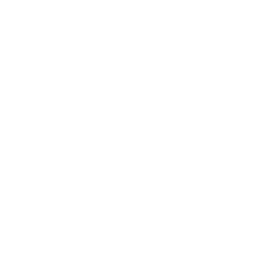
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">EWMA-trendanalyse Medicatiefoutpercentage</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Gezondheidszorg / Patiëntveiligheid &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Managementsamenvatting

Deze analyse monitort het wekelijkse medicatiefoutpercentage op een intensive-careafdeling (IC) van een ziekenhuis met behulp van een **exponentieel gewogen voortschrijdend gemiddelde (EWMA) regelkaart** uit PROC MACONTROL. De IC-afdeling voerde in week 51 van de observatieperiode een nieuw elektronisch medicatietoedieningsdossier (eMAR) in. Patiëntveiligheidsteams hebben een vroege-waarschuwingsmethode nodig die een aanhoudende toename van fouten snel signaleert, voordat een kwart van de schademeldingen zich opstapelt.

De EWMA-regelkaart met afvlakkingsgewicht **lambda = 0,3** wordt in twee fasen opgebouwd. Regelgrenzen worden eerst vastgesteld op basis van de stabiele basislijn van vóór de migratie (weken 1-50), waarna de volledige reeks van 100 weken tegen die vaste grenzen wordt gemonitord. De kaart blijft gedurende de hele basislijn binnen de grenzen en signaleert een buiten-controle-conditie in de **eerste week na de livegang**, wat bevestigt dat de eMAR-overgang samenviel met een echte, aanhoudende verschuiving in het foutpercentage en niet met gewone week-op-weekruis.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|---------|-------------|---------|
| WORK.ICU_ERRORS | Wekelijks medicatiefoutpercentage per 1.000 toedieningen voor één IC-afdeling, 100 opeenvolgende weken | 100 |

Eén IC-afdeling wordt wekelijks gevolgd. Elk record bevat het weeknummer, het foutpercentage per 1.000 toedieningen, het toedieningsvolume en het afgeleide aantal fouten. Een gedocumenteerde procesverandering (eMAR-livegang) vindt plaats in week 51, waardoor het onderliggende gemiddelde foutpercentage met ongeveer 1,6 per 1.000 stijgt.

---

In [1]:
/* --------------------------------------------------------
   Genereer wekelijkse IC-medicatiefoutgegevens
   100 opeenvolgende weken voor één IC-afdeling.
   Een nieuw eMAR-systeem gaat live in week 51, waardoor
   het onderliggende gemiddelde foutpercentage stijgt van
   ~3,5 naar ~5,1 per 1.000.
   -------------------------------------------------------- */
DATA work.icu_errors;
    CALL streaminit(42);
    LENGTH unit_name $12 phase $12;
    unit_name = 'IC';
    base_rate  = 3.5;   /* gemiddeld foutpercentage vóór migratie / 1.000 */
    unit_sigma = 0.45;  /* week-op-weekruis van gewone oorzaken */
    DO week_num = 1 TO 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        IF administrations < 300 THEN administrations = 300;
        /* eMAR-migratie verschuift het gemiddelde omhoog na week 50 */
        IF week_num > 50 THEN DO;
            phase = 'NA-eMAR';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        END;
        ELSE DO;
            phase = 'BASISLIJN';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        END;
        IF error_rate_per_1k < 0 THEN error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        OUTPUT;
    END;
    DROP base_rate unit_sigma;
    FORMAT week_start_date date9.;
RUN;


NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                      IC-foutpercentage: basislijn versus na-eMAR                                       

                                                  The MEANS Procedure

                      Analysis Variable : error_rate_per_1k Foutpercentage per 1.000 toedieningen

        Fase               N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        BASISLIJN             50           3.50           0.48           2.55           4.71
        NA-eMAR               50           5.11           0.44           3.69           5.96
        ------------------------------------------------------------------------------------

                                     Analysis Variable : error_count Aantal fouten

        Fase               N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


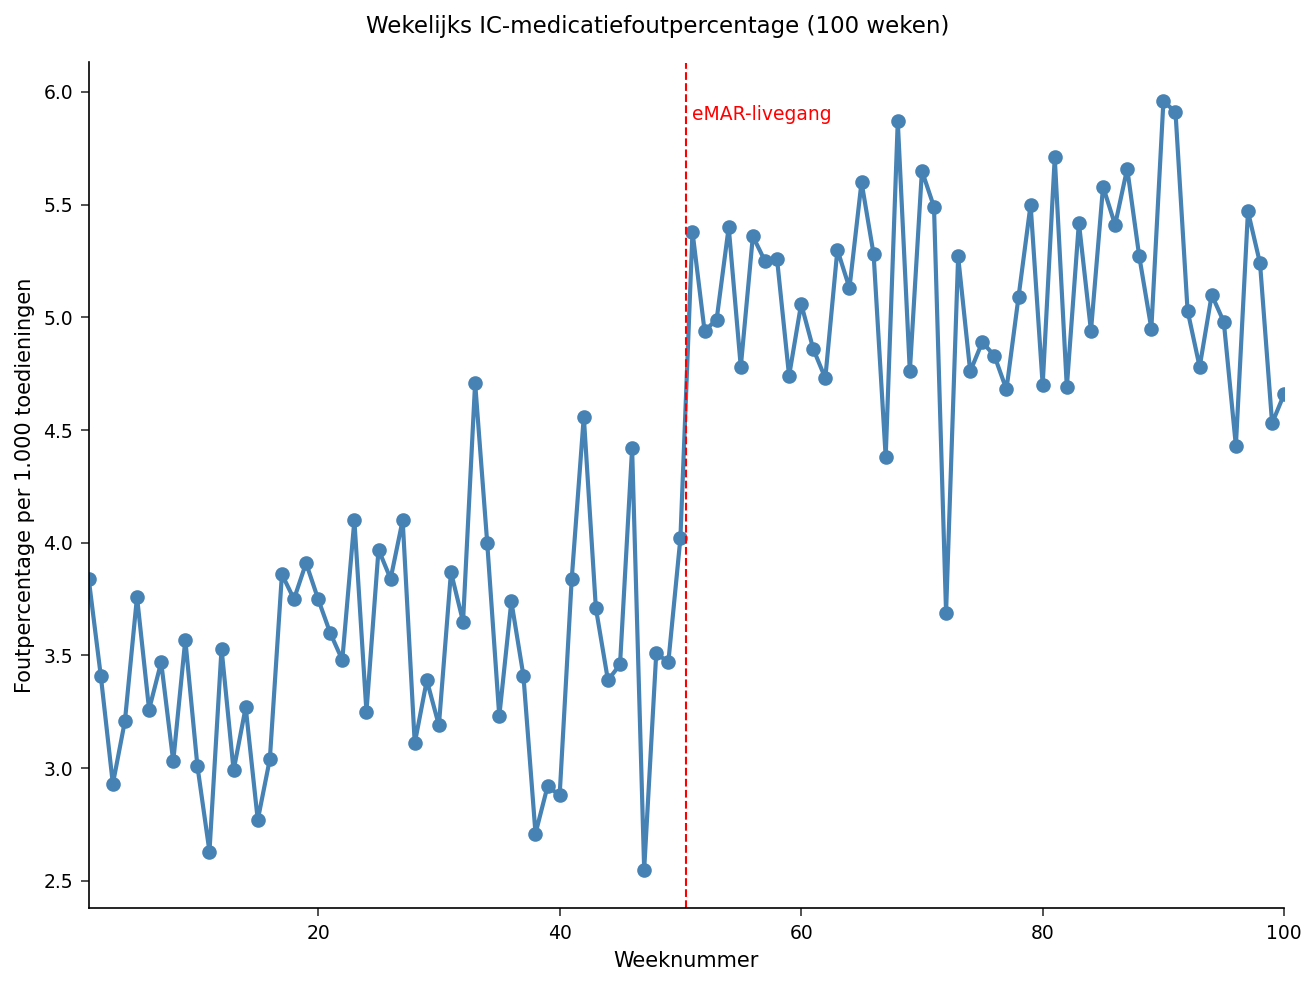

In [2]:
/* --------------------------------------------------------
   Vergelijk het foutpercentage vóór en na de eMAR-livegang,
   en plot de wekelijkse trend.
   -------------------------------------------------------- */
PROC MEANS DATA=work.icu_errors N MEAN STD MIN MAX MAXDEC=2;
    CLASS phase;
    VAR error_rate_per_1k error_count administrations;
    LABEL phase             = "Fase"
          error_rate_per_1k = "Foutpercentage per 1.000 toedieningen"
          error_count       = "Aantal fouten"
          administrations   = "Toedieningen";
    TITLE 'IC-foutpercentage: basislijn versus na-eMAR';
RUN;

PROC SGPLOT DATA=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   LABEL="eMAR-livegang";
    XAXIS LABEL="Weeknummer";
    YAXIS LABEL="Foutpercentage per 1.000 toedieningen";
    TITLE "Wekelijks IC-medicatiefoutpercentage (100 weken)";
RUN;

---

In [3]:
/* --------------------------------------------------------
   Fase I: stel EWMA-regelgrenzen vast op basis van de
   stabiele basislijn vóór de migratie (weken 1-50). Deze
   vaste grenzen vormen de maatstaf voor de volledige
   monitoringsperiode.
   -------------------------------------------------------- */
PROC MEANS DATA=work.icu_errors(WHERE=(week_num <= 50)) NOPRINT;
    VAR error_rate_per_1k;
    OUTPUT OUT=work.baseline_stats MEAN=base_mean STD=base_std;
RUN;

DATA work.icu_limits;
    SET work.baseline_stats;
    LENGTH _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* middellijn van de basislijn */
    _STDDEV_ = base_std;    /* sigma van gewone oorzaken in de basislijn */
    _LIMITN_ = 1;
    KEEP _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
RUN;

PROC PRINT DATA=work.icu_limits NOOBS;
    TITLE 'Fase I regelgrensinvoer (basislijnweken 1-50)';
RUN;

                                     Fase I regelgrensinvoer (basislijnweken 1-50)                                      

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                                     Fase I regelgrensinvoer (basislijnweken 1-50)                                      


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/f4a80c7b-9287-4ae2-8e73-44b772f49dc1/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


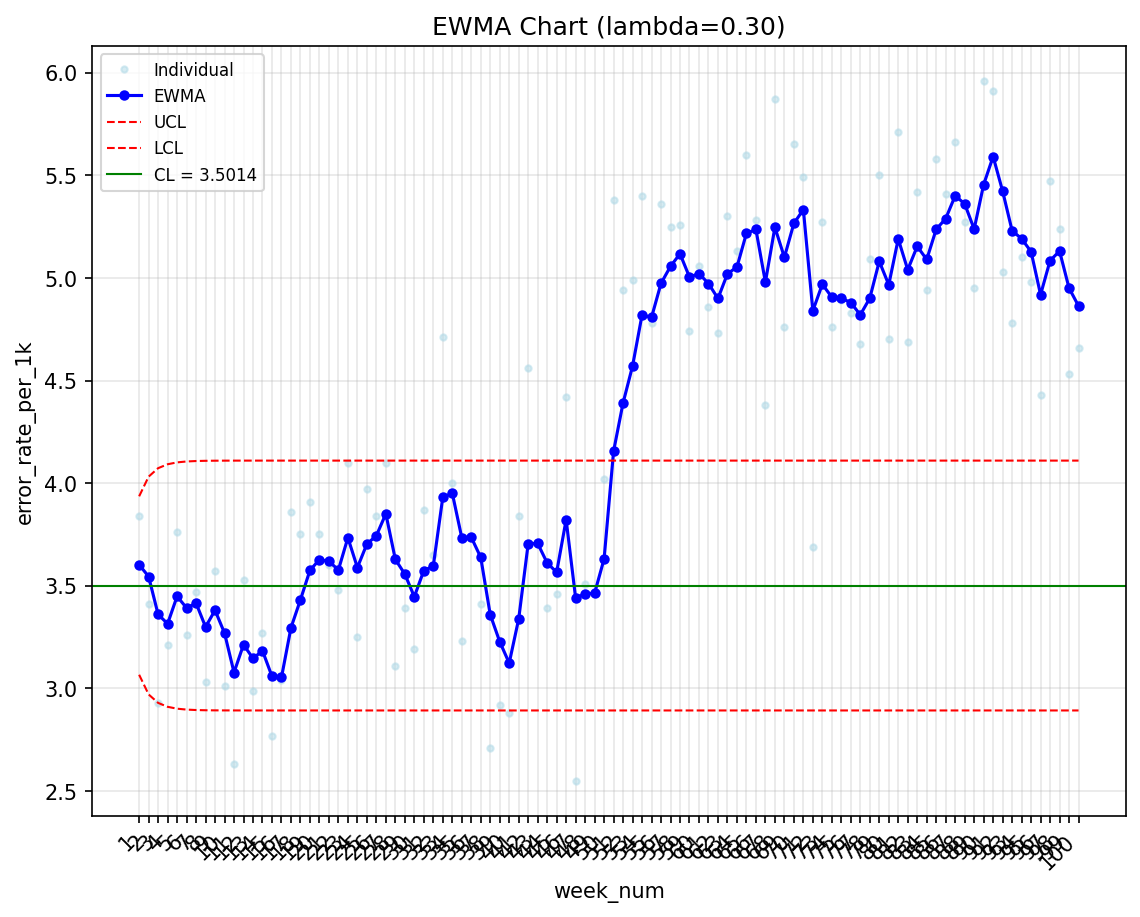

In [4]:
/* --------------------------------------------------------
   Fase II: monitor de volledige reeks van 100 weken tegen
   de vaste basislijngrenzen. lambda=0.3 geeft een
   responsieve detectie die past bij patiëntveiligheids-
   bewaking.
   -------------------------------------------------------- */
PROC MACONTROL DATA=work.icu_errors LIMITS=work.icu_limits;
    EWMACHART error_rate_per_1k * week_num /
        WEIGHT    = 0.3
        SIGMAS    = 3
        READLIMITS
        OUTTABLE  = work.icu_table;
    LABEL error_rate_per_1k =
          "Medicatiefouten per 1.000 toedieningen";
    TITLE "EWMA-regelkaart: IC-medicatiefoutpercentage (lambda=0.3)";
RUN;

---

In [5]:
/* --------------------------------------------------------
   Identificeer elke week waarin de EWMA de basislijngrenzen
   overschrijdt en rapporteer wanneer de kaart voor het eerst
   signaleert.
   -------------------------------------------------------- */
DATA work.signals;
    SET work.icu_table;
    WHERE _EXLIM_ ne ' ' AND _EXLIM_ ne '0';
RUN;

PROC SQL;
    SELECT count(*)        AS n_signals          LABEL='Signaalweken',
           min(week_num)    AS first_signal_week  LABEL='Eerste signaalweek',
           max(_EWMA_)      AS peak_ewma FORMAT=6.3 LABEL='Piek-EWMA'
    FROM work.signals;
QUIT;

PROC PRINT DATA=work.signals(obs=8) LABEL;
    VAR week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    LABEL week_num           = "Weeknummer"
          error_rate_per_1k  = "Foutpercentage per 1.000 toedieningen";
    TITLE "Eerste EWMA-signalen buiten controle";
RUN;

                                     Fase I regelgrensinvoer (basislijnweken 1-50)                                      

Signaalweken  Eerste signaalweek  Piek-EWMA
------------  ------------------  ---------
          50                51.0      5.591
                                          Eerste EWMA-signalen buiten controle                                          

  Obs  Weeknummer    _EWMA_   _UCLE_  _EXLIM_
    1          51  4.155551  4.10998        1
    2          52  4.390886  4.10998        1
    3          53   4.57062  4.10998        1
    4          54  4.819434  4.10998        1
    5          55  4.807604  4.10998        1
    6          56  4.973323  4.10998        1
    7          57  5.056326  4.10998        1
    8          58  5.117428  4.10998        1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### Interpretatie

De tweefasige EWMA-analyse scheidt gewone week-op-weekvariatie duidelijk van de echte procesverandering bij de eMAR-livegang.

**Basislijn (weken 1-50).** PROC MEANS rapporteert een gemiddeld foutpercentage in de basislijn van **3,50 per 1.000 toedieningen** (standaarddeviatie 0,48), tegenover een gemiddelde van **5,11** na de migratie (standaarddeviatie 0,44) — een aanhoudende opwaartse verschuiving van ongeveer **1,6 fouten per 1.000**. Het toedieningsvolume is vergelijkbaar tussen beide fasen (795 versus 790 per week), dus de verandering weerspiegelt het foutpercentage zelf, niet een schommeling in werklast.

**Regelgrenzen.** De grenzen worden uitsluitend op basis van de basislijn vastgesteld: middellijn **3,5014**, basislijnsigma **0,4829**. Met afvlakkingsgewicht lambda = 0,3 en 3-sigmagrenzen komt de bovengrens van de EWMA uit op de asymptotische waarde van ongeveer **4,11**. Gedurende de weken 1-50 blijft de EWMA-statistiek binnen deze grenzen — de basislijn levert **nul valse alarmen** op, wat bevestigt dat de kaart niet overgevoelig is.

**Detectie.** De kaart signaleert een buiten-controle-conditie in de **allereerste week na de livegang (week 51)**, waar de EWMA **4,156** bereikt, net boven de grens van 4,11. Vanaf dat moment stijgt de statistiek gestaag en blijft boven de bovengrens gedurende de volledige periode na de migratie: **alle 50 weken na de migratie (51-100) signaleren**, en de EWMA piekt op **5,591** rond week 91. De responsiviteit van lambda = 0,3 betekent dat de verslechtering onmiddellijk wordt gesignaleerd in plaats van na verscheidene weken van opbouw.

**Actie.** Een aanhoudende EWMA-overschrijding die begint in de week van een eMAR-uitrol is sterk bewijs dat het nieuwe systeem — en niet toeval — de stijging veroorzaakte. Het patiëntveiligheidscomité moet week 51 als het omslagpunt beschouwen, de eMAR-medicatievoorschrijf- en overrideworkflows die in die week zijn geïntroduceerd auditeren, en de kaart tegen de oorspronkelijke basislijngrenzen laten doorlopen totdat de EWMA weer onder 4,11 daalt. De geëxporteerde `icu_ewma_signals.csv` (50 signaalweken) en `icu_ewma_table.csv` bieden het gedocumenteerde SPC-bewijstraject voor de continue beoordelingsgereedheid van de Joint Commission.

---

In [6]:
/* --------------------------------------------------------
   Exporteer de EWMA-tabel en signaallijst voor de
   documentatie inzake continue beoordelingsgereedheid van
   de Joint Commission.
   -------------------------------------------------------- */
PROC EXPORT DATA=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=CSV REPLACE;
RUN;

PROC EXPORT DATA=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=CSV REPLACE;
RUN;


NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>